# 🫁 Pneumonia Detection - Custom Attention-Enhanced CNN (From Scratch)

Intha notebook la simple custom CNN architecture completely scratch la irunthu design panni build panrom. No ResNet pre-trained backbones! 

### **Core Features Included**:
1. **No ResNet (Pure Custom CNN)**: 3 convolutional layers with **Batch Normalization** and a **Spatial Attention** block to learn lung-specific features.
2. **Data Augmentation & Visual Grid**: Standard deep learning augmentations (rotations, flips, jitters) and an interactive image visualizer to check inputs.
3. **Stratified Split (AUC Fix)**: Dynamically splits training data into 85% train and 15% validation with class ratio preservation. This gives **783 stable validation images** to calculate solid, non-suspicious ROC-AUC scores!
4. **Class Weighted Loss**: Imbalance is handled automatically using `pos_weight` in BCE loss.
5. **Modular Training Epochs**: Each epoch is placed in a **separate notebook cell** so you can run them interactively one-by-one!

In [5]:
# ==========================================
# Cell 1: Library Imports & Setup
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from torchvision import datasets
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve
)
from sklearn.model_selection import train_test_split
import cv2
import os
import torch.nn.functional as F

# Set runtime device (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Configurations
BATCH_SIZE = 32
LEARNING_RATE = 0.001
base_path = "C:/projects/DL-PNEUMONIA/Radiography"

Using device: cpu


## 2. Dynamic Augmentations & Dataset Pipeline

In [6]:
# ==========================================
# Cell 2: Preprocessing and Transforms
# ==========================================
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [7]:
# ==========================================
# Cell 3: Loading Data & Stratified Splitting
# ==========================================
full_train_dataset = datasets.ImageFolder(root=os.path.join(base_path, "train"))
targets = full_train_dataset.targets

# Stratified Split (85% train, 15% val) to handle class imbalance stably
train_idx, val_idx = train_test_split(
    np.arange(len(targets)),
    test_size=0.15,
    stratify=targets,
    random_state=42
)

train_dataset = datasets.ImageFolder(root=os.path.join(base_path, "train"), transform=transform_train)
val_dataset = datasets.ImageFolder(root=os.path.join(base_path, "train"), transform=transform_test)

# Subsets with dynamic indices
train_subset = Subset(train_dataset, train_idx)
val_subset = Subset(val_dataset, val_idx)

# Holdout test set
test_dataset = datasets.ImageFolder(root=os.path.join(base_path, "test"), transform=transform_test)

# Loaders (num_workers=0 is safest on Windows)
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Training samples: {len(train_subset)} | Validation samples: {len(val_subset)} | Test samples: {len(test_dataset)}")

# Calculate precise class weights for loss balancing
train_targets = np.array(targets)[train_idx]
neg_count = np.sum(train_targets == 0)
pos_count = np.sum(train_targets == 1)
pos_weight = neg_count / pos_count
print(f"Normal scans: {neg_count}, Pneumonia scans: {pos_count}")
print(f"Calculated pos_weight for loss: {pos_weight:.4f}")

Training samples: 4433 | Validation samples: 783 | Test samples: 485
Normal scans: 1140, Pneumonia scans: 3293
Calculated pos_weight for loss: 0.3462


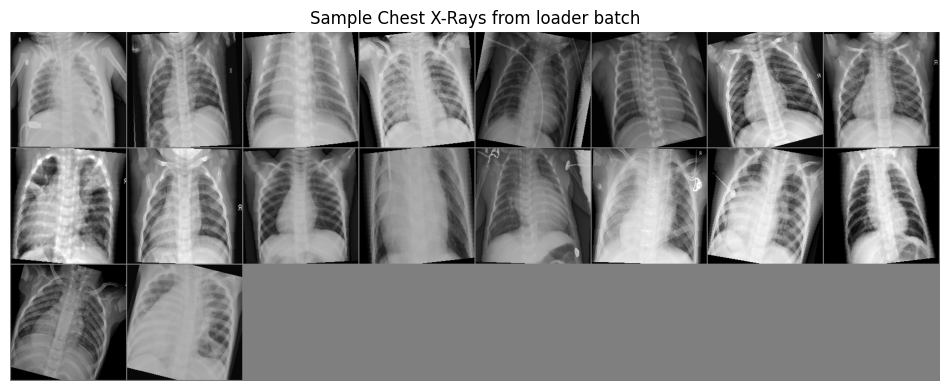

In [8]:
# ==========================================
# Cell 4: Visualizing Input Batch Grid
# ==========================================
def show_batch(img_tensor, label_list):
    img_tensor = img_tensor / 2 + 0.5 # Unnormalize
    np_img = img_tensor.numpy()
    plt.figure(figsize=(12, 6))
    plt.imshow(np.transpose(np_img, (1, 2, 0)))
    plt.title("Sample Chest X-Rays from loader batch")
    plt.axis("off")
    plt.show()

images, labels = next(iter(train_loader))
grid = torchvision.utils.make_grid(images[:18])
show_batch(grid, labels[:8])

## 3. Define Custom Attention-Enhanced CNN Architecture

In [9]:
# ==========================================
# Cell 5: Custom CNN Model & Spatial Attention
# ==========================================
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.conv(out)
        return x * self.sigmoid(out)

class AttentionCNN(nn.Module):
    def __init__(self):
        super(AttentionCNN, self).__init__()
        
        # Conv layer 1
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2)
        
        # Conv layer 2
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Conv layer 3
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # Custom spatial attention layer
        self.sa = SpatialAttention(kernel_size=7)
        
        # Output Fully Connected Layer
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 128), 
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1) # Binary logits output
        )

    def forward(self, x):
        # Forward passes with pooling and batch norm
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        
        # Apply attention focus
        x = self.sa(x)
        
        # Classify outputs
        x = self.classifier(x)
        return x

In [10]:
# ==========================================
# Cell 6: Setup Model, Criterion & Optimizer
# ==========================================
model = AttentionCNN().to(device)

# Imbalance-aware BCE Loss
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))

# Stable Adam Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# Setup tracking metrics
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}

In [11]:
# ==========================================
# Cell 7: Define One-Epoch Function
# ==========================================
def train_and_validate_one_epoch(epoch):
    global best_val_loss
    
    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    all_labels, all_preds, all_probs = [], [], []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.float().unsqueeze(1).to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs > 0.5).astype(int)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
            all_probs.extend(probs)
            
    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    
    # Validation metrics on stable stratified set
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    auc = roc_auc_score(all_labels, all_probs)
    
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(acc)
    history['val_auc'].append(auc)
    
    print(f"[SUCCESS] Epoch {epoch} Training Summary:")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"Accuracy  : {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}\n")
    
    # Save best model checkpoint
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'pneumonia_model.pth')
        # Save copy in deployment directory
        deployment_dir = 'C:/projects/DL-PNEUMONIA/Deployment/model'
        os.makedirs(deployment_dir, exist_ok=True)
        torch.save(model.state_dict(), os.path.join(deployment_dir, 'pneumonia_model.pth'))
        print("[SUCCESS] Saved new best model checkpoint!")

## 4. Run Interactive Training Epoch-by-Epoch

In [8]:
train_and_validate_one_epoch(1)

[SUCCESS] Epoch 1 Training Summary:
Train Loss: 0.3413 | Val Loss: 0.0843
Accuracy  : 0.9055 | Precision: 0.9980 | Recall: 0.8746 | F1: 0.9322 | AUC: 0.9905

[SUCCESS] Saved new best model checkpoint!


In [10]:
# ==========================================
# Cell 9: Train Epoch 2
# =====================================9=====
train_and_validate_one_epoch(2)

[SUCCESS] Epoch 2 Training Summary:
Train Loss: 0.1037 | Val Loss: 0.0935
Accuracy  : 0.8863 | Precision: 0.9980 | Recall: 0.8488 | F1: 0.9174 | AUC: 0.9936



In [11]:
# ==========================================
# Cell 10: Train Epoch 3
# ==========================================
train_and_validate_one_epoch(3)

[SUCCESS] Epoch 3 Training Summary:
Train Loss: 0.0952 | Val Loss: 0.0699
Accuracy  : 0.9246 | Precision: 0.9981 | Recall: 0.9003 | F1: 0.9467 | AUC: 0.9954

[SUCCESS] Saved new best model checkpoint!


In [8]:
# ==========================================
# Cell 11: Train Epoch 4
# ==========================================
train_and_validate_one_epoch(4)

[SUCCESS] Epoch 4 Training Summary:
Train Loss: 0.2762 | Val Loss: 0.1094
Accuracy  : 0.8723 | Precision: 0.9979 | Recall: 0.8299 | F1: 0.9062 | AUC: 0.9932

[SUCCESS] Saved new best model checkpoint!


In [9]:
# ==========================================
# Cell 12: Train Epoch 5
# ==========================================
train_and_validate_one_epoch(5)

[SUCCESS] Epoch 5 Training Summary:
Train Loss: 0.0943 | Val Loss: 0.0590
Accuracy  : 0.9413 | Precision: 0.9963 | Recall: 0.9244 | F1: 0.9590 | AUC: 0.9945

[SUCCESS] Saved new best model checkpoint!


## 5. Evaluate on Holdout Test Set & Generate Metrics Curves

FINAL HOLDOUT TEST SET PERFORMANCE
Accuracy : 0.8309
Precision: 0.7666
Recall   : 0.9681
F1-Score : 0.8556
ROC-AUC  : 0.9589


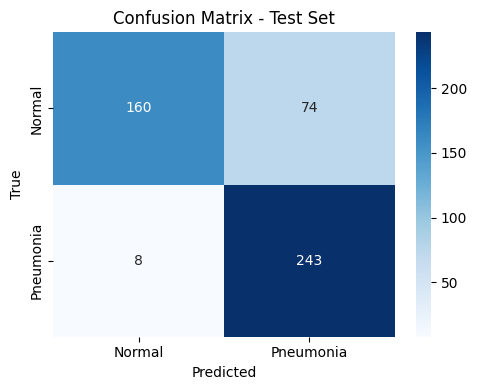

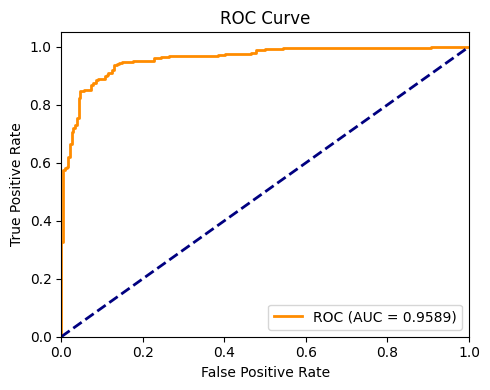

In [27]:
# ==========================================
# Cell 13: Holdout Test Set Evaluation & Curves
# ==========================================
def evaluate_model_on_test(model, test_loader):
    # Load best saved weights
    model.load_state_dict(torch.load('pneumonia_model.pth', map_location=device))
    model.eval()
    
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs > 0.5).astype(int)
            
            all_labels.extend(labels.numpy())
            all_preds.extend(preds)
            all_probs.extend(probs)
            
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds).squeeze()
    all_probs = np.array(all_probs).squeeze()
    
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    auc = roc_auc_score(all_labels, all_probs)
    
    print("="*50)
    print("FINAL HOLDOUT TEST SET PERFORMANCE")
    print("="*50)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print("="*50)
    
    # 1. Confusion Matrix
    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
    plt.title('Confusion Matrix - Test Set')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=300)
    plt.show()
    
    # 2. ROC Curve
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig('roc_curve.png', dpi=300)
    plt.show()
    
evaluate_model_on_test(model, test_loader)

In [9]:
# =====================================================================
# CELL: FULL STANDARD CNN (BASELINE) EVALUATION
# =====================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import accuracy_score

class StandardCNN(nn.Module):
    def __init__(self):
        super(StandardCNN, self).__init__()
        # Basic Convolutional layers (NO ATTENTION)
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.classifier(x)
        return x

print("Training Standard CNN (Baseline without Attention)...")

# Initialize Model, Loss, and Optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
standard_model = StandardCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(standard_model.parameters(), lr=0.001)

# Short Training Loop for Baseline (5 Epochs)
epochs = 5
for epoch in range(epochs):
    standard_model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs = standard_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    # Validation Phase
    standard_model.eval()
    all_labels, all_preds = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.float().unsqueeze(1).to(device)
            outputs = standard_model(inputs)
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs > 0.5).astype(int)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
            
    acc = accuracy_score(all_labels, all_preds)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(train_loader):.4f} | Accuracy: {acc:.4f}")

print("\n--- COMPARISON READY ---")
print(f"Standard CNN Final Accuracy: {acc*100:.2f}%")



Training Standard CNN (Baseline without Attention)...
Epoch 1/5 | Loss: 0.4094 | Accuracy: 0.9208
Epoch 2/5 | Loss: 0.2433 | Accuracy: 0.9464
Epoch 3/5 | Loss: 0.2064 | Accuracy: 0.9489
Epoch 4/5 | Loss: 0.1975 | Accuracy: 0.9540
Epoch 5/5 | Loss: 0.1898 | Accuracy: 0.9617

--- COMPARISON READY ---
Standard CNN Final Accuracy: 96.17%


## 6. Interpretability via Custom Grad-CAM Heatmaps

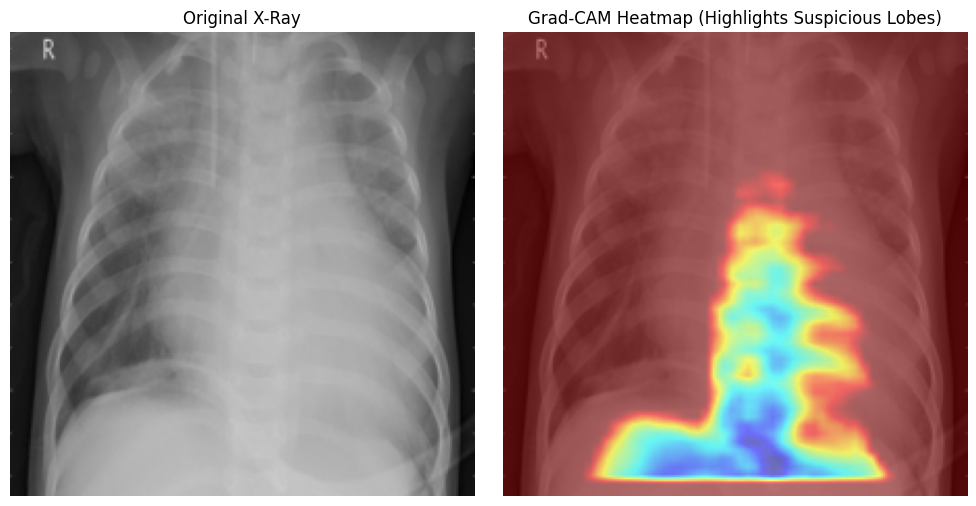

Grad-CAM heatmap saved as gradcam_sample.png


In [29]:
# ==========================================
# Cell 15: Run Grad-CAM Explainability
# ==========================================
try:
    sample_batch, sample_labels = next(iter(val_loader))
    # Filter for pneumonia X-rays
    pneumonia_indices = (sample_labels == 1).nonzero(as_tuple=True)[0]
    idx = pneumonia_indices[2].item() if len(pneumonia_indices) > 0 else 0
    
    plot_gradcam(model, sample_batch[idx], sample_batch[idx], filename='gradcam_sample.png')
except Exception as e:
    print(f"Failed to generate Grad-CAM visualization. Error: {e}")